In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
os.listdir('/kaggle/input')

['spam-vs-ham-emails']

In [3]:
os.listdir('/kaggle/input/spam-vs-ham-emails')

['email_spam_dataset.csv']

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [5]:
df = pd.read_csv('/kaggle/input/spam-vs-ham-emails/email_spam_dataset.csv')
print(df.head())

                                          email_text label
0          Here is the project update you asked for.   ham
1     Limited offer!!! Buy now and get 50% discount.  spam
2  Win cash prizes instantly by replying to this ...  spam
3  Urgent! Your account has been suspended. Verif...  spam
4       Hi, please find the meeting agenda attached.   ham


In [23]:
df.columns = ['label', 'text']
def text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text
    data['text'] = data['text'].apply(clean_text)
    #Converting Labels to Numbers ham = 0, spam = 1
    df['label'] = df['label'].map({'ham': 0, 'spam': 1})
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['text'])
Y = df['label']
y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy * 100)

Accuracy: 32.8125


In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [13]:
model = MultinomialNB(alpha = 0.1)
model.fit(X_train, Y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(Y_test, predictions)
print("Accuracy:", accuracy)
def check_email(email):
    email = text(email)
    email_vector = vectorizer.transform([email])
    result = model.predict(email_vector)
    if result[0] == 1:
        print("SPAM")
    else:
        print("HAM")
check_email("Congratulations! You have won a free prize. Click now")

Accuracy: 0.328125
HAM


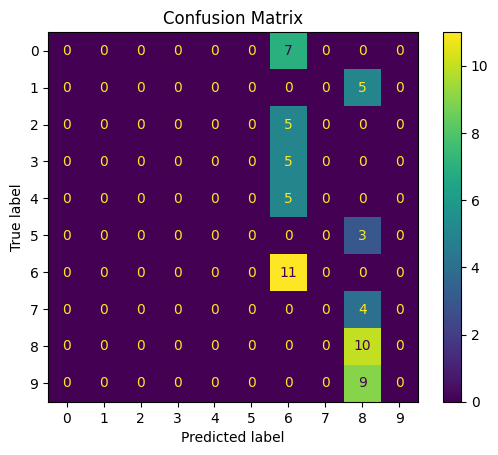

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

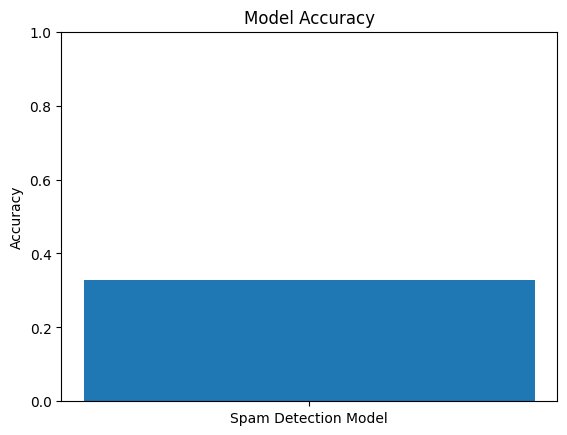

In [26]:
plt.figure()
plt.bar(['Spam Detection Model'], [accuracy])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.show()